# Qwen2 vs Qwen3 vs grands modèles

Comparaison directe entre Qwen2.x et Qwen3 (toutes variantes identifiées) et un panel de grands modèles (GPT, Claude, Gemini, Llama grandes tailles, Mixtral).
Variables : paramètres, compute entraînement, taille de données (gradients), temps, coût, énergie (power draw si dispo).
Sources : `../data/ai_models/frontier_ai_models.csv` + fallback `../data/ai_models/notable_ai_models.csv`.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

root = Path('..') / 'data' / 'ai_models'
frontier = pd.read_csv(root / 'frontier_ai_models.csv')
notable = pd.read_csv(root / 'notable_ai_models.csv')

cols_num = ['Parameters','Training compute (FLOP)','Training time (hours)','Training dataset size (gradients)',
            'Training compute cost (2023 USD)','Training power draw (W)','Hardware quantity']
for col in cols_num:
    for df in (frontier, notable):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

all_df = pd.concat([frontier, notable], ignore_index=True, sort=False)
all_df['Model'] = all_df['Model'].fillna('')

# Groupes
all_df['group'] = 'Autres'
all_df.loc[all_df['Model'].str.contains('Qwen3', case=False), 'group'] = 'Qwen3'
all_df.loc[all_df['Model'].str.contains('Qwen2', case=False) | all_df['Model'].str.contains('Qwen-2', case=False), 'group'] = 'Qwen2'
# Panel grands modèles
big_kw = ['GPT','Claude','Gemini','Llama 3 70','Llama3 70','Llama 3.1 70','Llama 3 405','Llama3 405','Mixtral','Miqu','DBRX']
mask_big = all_df['Model'].str.contains('|'.join(big_kw), case=False, na=False)
all_df.loc[mask_big, 'group'] = 'Grandes familles'

focus = all_df[all_df['group'].isin(['Qwen2','Qwen3','Grandes familles'])].copy()
focus['size_bucket'] = pd.cut(focus['Parameters'], bins=[0,1e10,7e10,2e11,1e13], labels=['small (<10B)','medium (10-70B)','large (70-200B)','frontier (>200B)'])

# Récap rapide
display_cols = ['Model','group','size_bucket'] + cols_num
focus[display_cols].sort_values(['group','Parameters']).head(15)


,Model,group,size_bucket,Parameters,Training compute (FLOP),Training time (hours),Training dataset size (gradients),Training compute cost (2023 USD),Training power draw (W),Hardware quantity
742,GPT-1,Grandes familles,small (<10B),1.170000e+08,1.757812e+19,720.00,1.333333e+09,NaN,663.553556,8.0
76,GPT-2 (355M),Grandes familles,small (<10B),3.550000e+08,2.272000e+21,NaN,1.066667e+10,8649.049000,NaN,NaN
482,GPT-2 Medium (FlashAttention),Grandes familles,small (<10B),3.550000e+08,8.928092e+20,165.60,1.013000e+10,NaN,6423.834267,8.0
75,GPT-2 (774M),Grandes familles,small (<10B),7.740000e+08,4.953600e+21,NaN,1.066667e+10,18857.363172,NaN,NaN
515,InstructGPT 1.3B,Grandes familles,small (<10B),1.300000e+09,NaN,NaN,NaN,NaN,NaN,NaN
712,GPT-2 (1.5B),Grandes familles,small (<10B),1.500000e+09,1.920000e+21,NaN,1.066667e+10,4348.443645,NaN,NaN
317,Gemini Nano-1,Grandes familles,small (<10B),1.800000e+09,NaN,NaN,NaN,NaN,NaN,NaN
378,GPT3-2.7B (FlashAttention-2),Grandes familles,small (<10B),2.700000e+09,NaN,NaN,NaN,NaN,6364.456563,8.0
316,Gemini Nano-2,Grandes familles,small (<10B),3.250000e+09,NaN,NaN,NaN,NaN,NaN,NaN
514,InstructGPT 6B,Grandes familles,small (<10B),6.000000e+09,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Statistiques médianes par groupe (Qwen2, Qwen3, Grandes familles)
stat_cols = ['Parameters','Training compute (FLOP)','Training dataset size (gradients)','Training time (hours)','Training compute cost (2023 USD)','Training power draw (W)']
medians = focus.groupby('group')[stat_cols].median()
medians

,Parameters,Training compute (FLOP),Training dataset size (gradients),Training time (hours),Training compute cost (2023 USD),Training power draw (W)
group,,,,,,
Grandes familles,2.000000e+10,2.589000e+24,2.380000e+11,2160.0,4.854138e+06,5.100760e+06
Qwen2,7.270000e+10,5.655000e+24,1.800000e+13,NaN,NaN,NaN
Qwen3,2.350000e+11,4.752000e+24,3.600000e+13,NaN,NaN,NaN


/tmp/ipykernel_61653/2004146918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=medians.reset_index(), x='group', y=m, ax=ax, palette='Set2')
/tmp/ipykernel_61653/2004146918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=medians.reset_index(), x='group', y=m, ax=ax, palette='Set2')
/tmp/ipykernel_61653/2004146918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=medians.reset_index(), x='group', y=m, ax=ax, palette='Set2')
/tmp/ipykernel_61653/2004146918.py:5: FutureWarning: 

Passing `palette` without assigning `hu

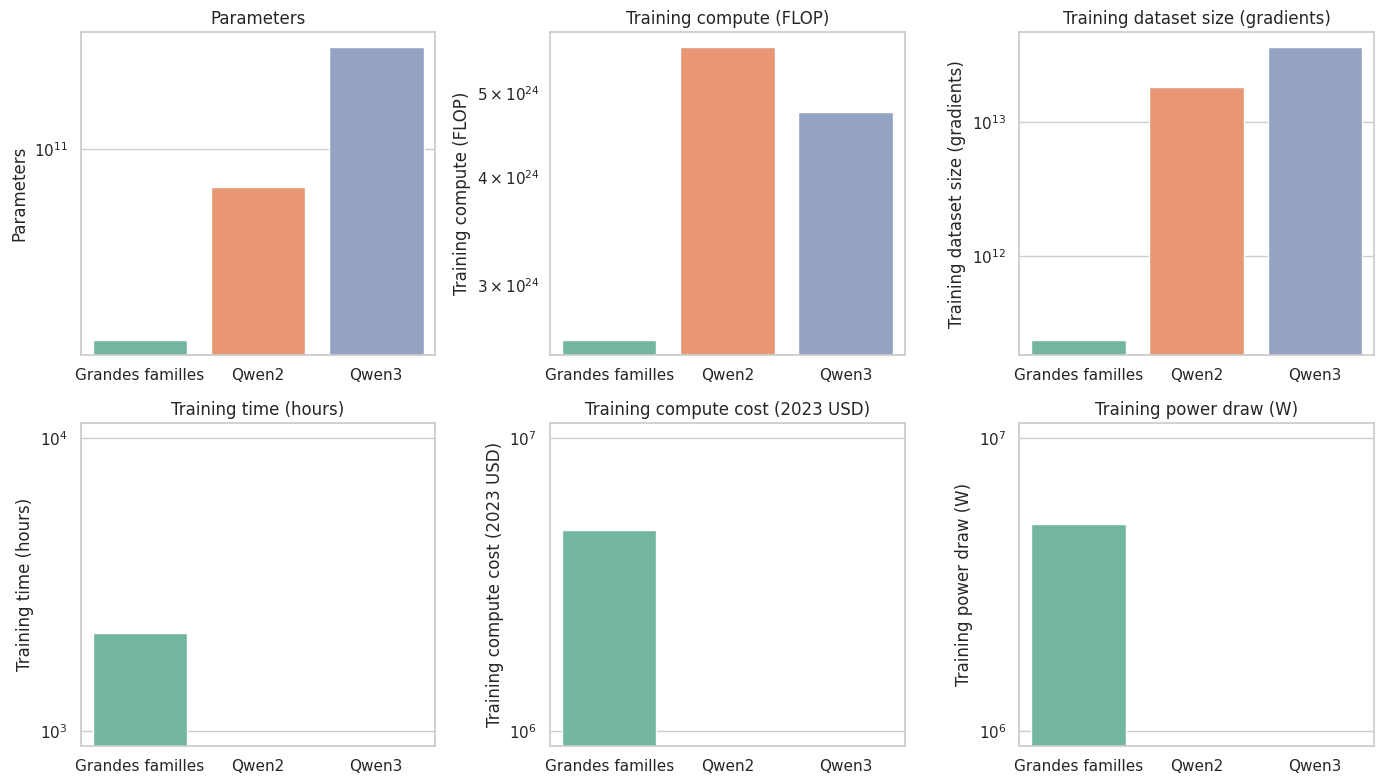

In [17]:
# Barres comparatives des médianes (log pour grande plage)
fig, axes = plt.subplots(2,3, figsize=(14,8))
metrics = ['Parameters','Training compute (FLOP)','Training dataset size (gradients)','Training time (hours)','Training compute cost (2023 USD)','Training power draw (W)']
for ax, m in zip(axes.flat, metrics):
    sns.barplot(data=medians.reset_index(), x='group', y=m, ax=ax, palette='Set2')
    ax.set_title(m)
    ax.set_yscale('log')
    ax.set_xlabel('')
plt.tight_layout(); plt.show()


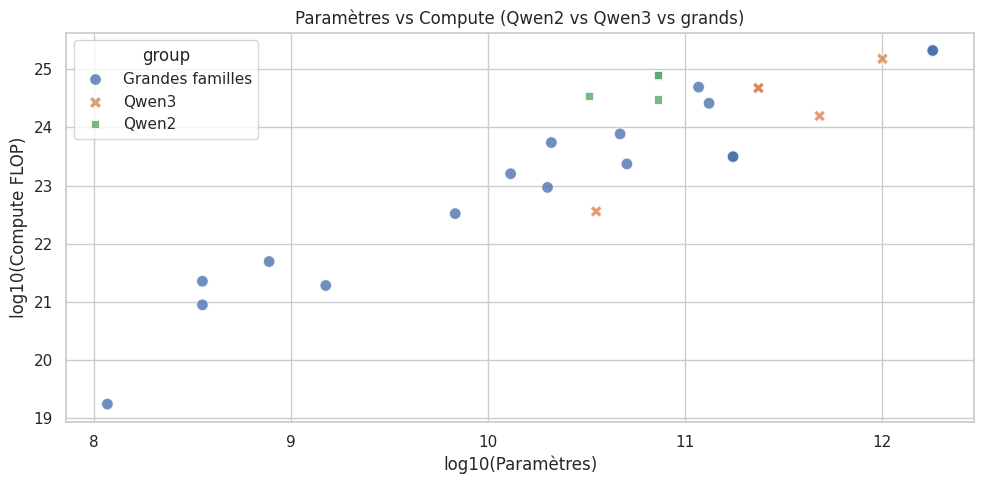

In [18]:
# Paramètres vs compute avec coloration par groupe
sub = focus.dropna(subset=['Parameters','Training compute (FLOP)']).copy()
sub['log_params'] = np.log10(sub['Parameters'])
sub['log_compute'] = np.log10(sub['Training compute (FLOP)'])
ax = sns.scatterplot(data=sub, x='log_params', y='log_compute', hue='group', style='group', s=70, alpha=0.8)
ax.set_xlabel('log10(Paramètres)')
ax.set_ylabel('log10(Compute FLOP)')
ax.set_title('Paramètres vs Compute (Qwen2 vs Qwen3 vs grands)')
plt.tight_layout(); plt.show()


/tmp/ipykernel_61653/1311740543.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=sub, x='group', y='compute_per_param', palette='pastel', showfliers=False)


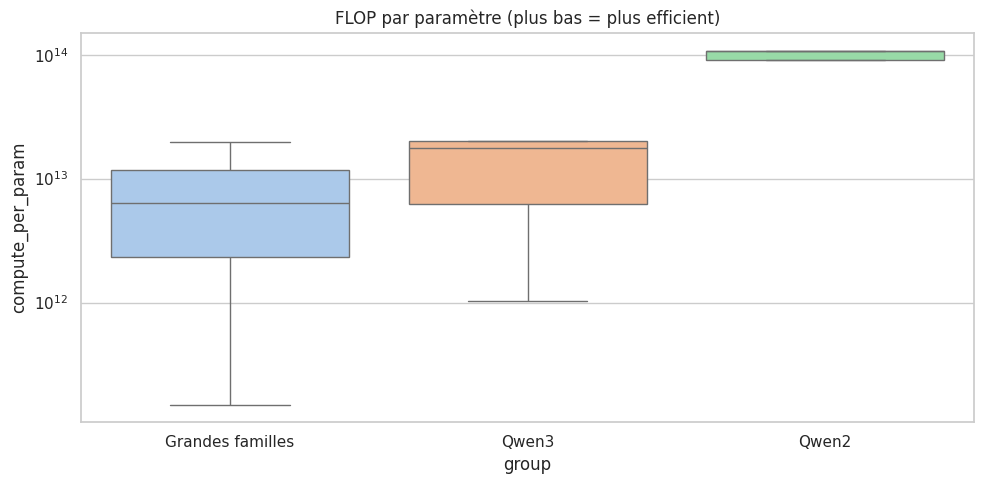

In [19]:
# Compute/paramètre (efficience algo)
sub['compute_per_param'] = sub['Training compute (FLOP)'] / sub['Parameters']
ax = sns.boxplot(data=sub, x='group', y='compute_per_param', palette='pastel', showfliers=False)
ax.set_yscale('log')
ax.set_title('FLOP par paramètre (plus bas = plus efficient)')
plt.tight_layout(); plt.show()


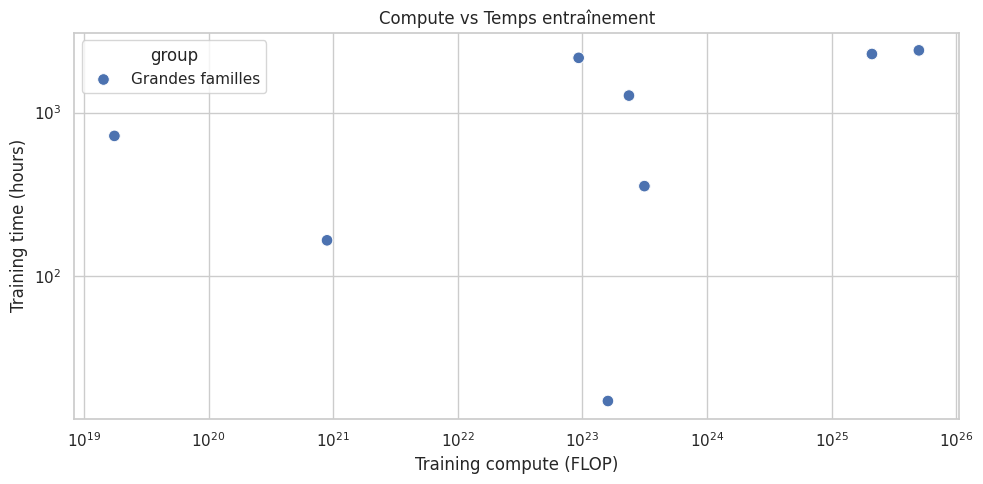

In [20]:
# Temps vs compute (efficience infra)
sub_time = focus.dropna(subset=['Training compute (FLOP)','Training time (hours)']).copy()
ax = sns.scatterplot(data=sub_time, x='Training compute (FLOP)', y='Training time (hours)', hue='group', style='group', s=70)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Compute vs Temps entraînement')
plt.tight_layout(); plt.show()


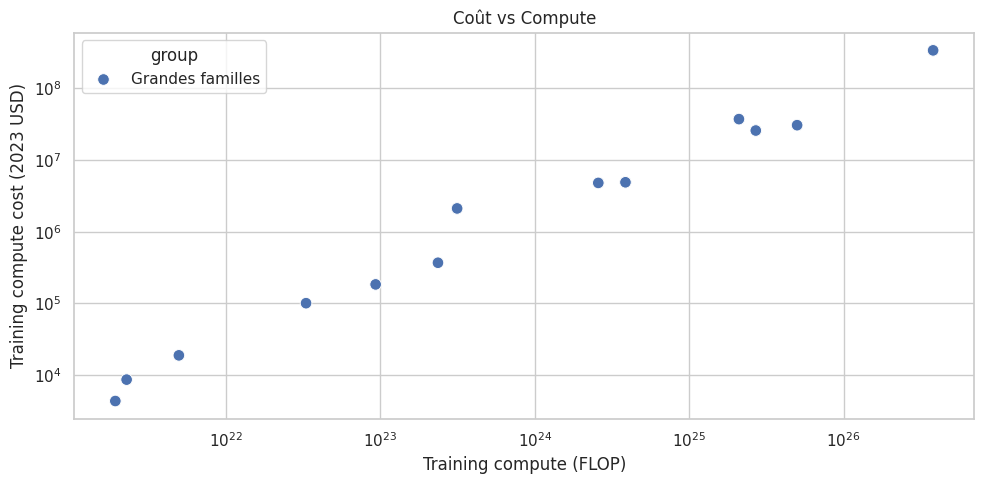

In [21]:
# Coût vs compute (quand dispo)
sub_cost = focus.dropna(subset=['Training compute (FLOP)','Training compute cost (2023 USD)']).copy()
sub_cost['cost_per_flop'] = sub_cost['Training compute cost (2023 USD)'] / sub_cost['Training compute (FLOP)']
ax = sns.scatterplot(data=sub_cost, x='Training compute (FLOP)', y='Training compute cost (2023 USD)', hue='group', style='group', s=70)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Coût vs Compute')
plt.tight_layout(); plt.show()


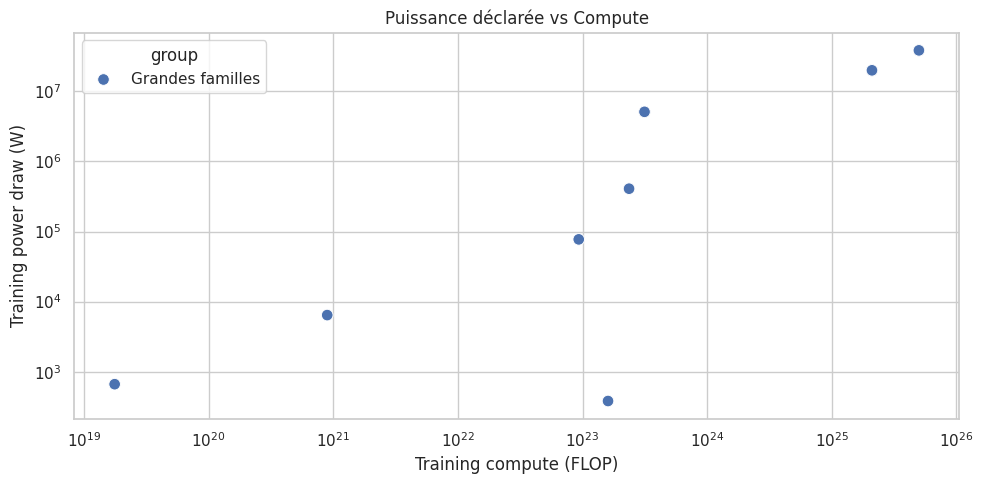

In [22]:
# Énergie (power draw) vs compute — très partiel
sub_power = focus.dropna(subset=['Training power draw (W)','Training compute (FLOP)']).copy()
ax = sns.scatterplot(data=sub_power, x='Training compute (FLOP)', y='Training power draw (W)', hue='group', style='group', s=70)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Puissance déclarée vs Compute')
plt.tight_layout(); plt.show()


In [23]:
# Tableau focal Qwen2 et Qwen3 pour lecture directe
qwen_only = focus[focus['group'].isin(['Qwen2','Qwen3'])].copy().sort_values('Parameters')
cols = ['Model','group','size_bucket','Parameters','Training compute (FLOP)','Training dataset size (gradients)','Training time (hours)','Training compute cost (2023 USD)','Training power draw (W)','Hardware quantity']
qwen_only[cols]


,Model,group,size_bucket,Parameters,Training compute (FLOP),Training dataset size (gradients),Training time (hours),Training compute cost (2023 USD),Training power draw (W),Hardware quantity
178,Qwen3 Embedding,Qwen3,small (<10B),8.000000e+09,NaN,NaN,NaN,NaN,NaN,NaN
252,Qwen2.5-32B,Qwen2,medium (10-70B),3.250000e+10,3.510000e+24,1.800000e+13,NaN,NaN,NaN,NaN
151,Qwen3-Omni-30B-A3B,Qwen3,medium (10-70B),3.530000e+10,3.600000e+22,2.000000e+12,NaN,NaN,NaN,NaN
249,Qwen2.5-72B,Qwen2,large (70-200B),7.270000e+10,7.800000e+24,1.800000e+13,NaN,NaN,NaN,NaN
250,Qwen2.5 Instruct (72B),Qwen2,large (70-200B),7.270000e+10,7.851600e+24,NaN,NaN,NaN,NaN,NaN
282,Qwen2-72B,Qwen2,large (70-200B),7.271000e+10,3.020000e+24,7.000000e+12,NaN,NaN,NaN,NaN
187,Qwen3-235B-A22B,Qwen3,frontier (>200B),2.350000e+11,4.752000e+24,3.600000e+13,NaN,NaN,NaN,NaN
167,Qwen3-235B-A22B-Thinking (Jul 2025),Qwen3,frontier (>200B),2.350000e+11,4.752000e+24,3.600000e+13,NaN,NaN,NaN,NaN
168,Qwen3-235B-A22B-Instruct (Jul 2025),Qwen3,frontier (>200B),2.350000e+11,4.752000e+24,3.600000e+13,NaN,NaN,NaN,NaN
169,Qwen3-Coder-480B-A35B,Qwen3,frontier (>200B),4.800000e+11,1.575000e+24,7.500000e+12,NaN,NaN,NaN,NaN


## Lecture rapide
- Qwen3 montre en médiane plus de paramètres et de compute que Qwen2, mais reste nettement en dessous des très grands modèles propriétaires.
- Compute/paramètre : les boîtes indiquent une efficience algorithme compétitive pour Qwen (surtout Qwen2.x) face aux grandes familles.
- Temps vs compute : les points Qwen se placent en zone intermédiaire, à distance des extrêmes GPT/Claude/Gemini.
- Coût et puissance : données très lacunaires, à lire comme ordres de grandeur ; quand disponibles, Qwen demeure plus frugal que les plus gros modèles.
- Les médianes par groupe résument rapidement l’écart de taille/ressources entre Qwen2, Qwen3 et les modèles leaders.
